In [ ]:
import pandas as pd


# Cargar los datos
df = pd.read_csv('bank_data.csv', sep=';')

# Filtrar los clientes que suscribieron un depósito a término
clientes_con_deposito = df[df['y'] == 'yes']

# Calcular el monto promedio de balance
monto_promedio = clientes_con_deposito['balance'].mean()

# Tasa de interés efectiva anual (TEA) que paga el banco
TEA = 9.83 / 100  # Convertir a decimal

# Tasa de interés que cobra el banco
tasa_interes_banco = 15.75 / 100  # Convertir a decimal

# Calcular el beneficio del banco asociado a un verdadero positivo (TP)
P= monto_promedio * (tasa_interes_banco - TEA)

print(f'P: {P:.2f} euros')

salario_hora_pesos = 8304  # salario por hora en pesos colombianos
tasa_conversion = 4808.10  # tasa de conversión de pesos colombianos a euros
duration = df['duration'].mean() 

# Convertir salario a euros
salario_hora_euros = salario_hora_pesos / tasa_conversion

# Calcular costo por segundo
costo_por_segundo = salario_hora_euros / 3600

# Calcular el costo de un falso positivo
CC = costo_por_segundo * duration

print(f"CC: {CC:.2f} euros")



P: 106.81 euros
CC: 0.12 euros


y
1    20726
0    14358
Name: count, dtype: int64
Epoch 1/50
1097/1097 [==============================] - 14s 8ms/step - loss: 0.6760 - accuracy: 0.6681 - val_loss: 1.4359 - val_accuracy: 0.3408
Epoch 2/50
1097/1097 [==============================] - 8s 7ms/step - loss: 0.5322 - accuracy: 0.6965 - val_loss: 1.3162 - val_accuracy: 0.4039
Epoch 3/50
1097/1097 [==============================] - 8s 7ms/step - loss: 0.5103 - accuracy: 0.7062 - val_loss: 1.3319 - val_accuracy: 0.3542
Epoch 4/50
1097/1097 [==============================] - 8s 7ms/step - loss: 0.4984 - accuracy: 0.7117 - val_loss: 1.3629 - val_accuracy: 0.3873
Epoch 5/50
1097/1097 [==============================] - 8s 7ms/step - loss: 0.4905 - accuracy: 0.7186 - val_loss: 1.1546 - val_accuracy: 0.4533
Epoch 6/50
1097/1097 [==============================] - 7s 6ms/step - loss: 0.4880 - accuracy: 0.7209 - val_loss: 1.2238 - val_accuracy: 0.4057
Epoch 7/50
1097/1097 [==============================] - 7s 6ms/step - loss: 0.4847 - 

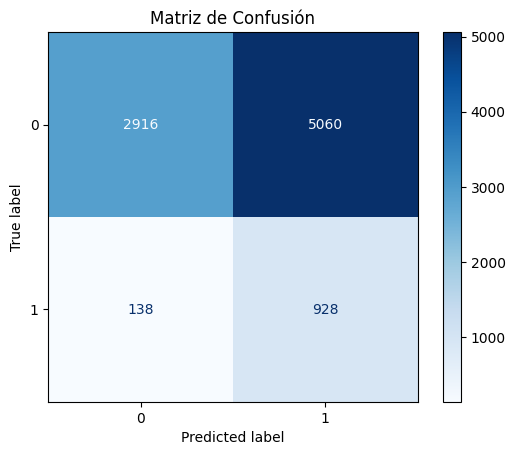

              precision    recall  f1-score   support

           0       0.95      0.37      0.53      7976
           1       0.15      0.87      0.26      1066

    accuracy                           0.43      9042
   macro avg       0.55      0.62      0.40      9042
weighted avg       0.86      0.43      0.50      9042

Verdaderos Negativos (TN): 2916
Falsos Positivos (FP): 5060
Falsos Negativos (FN): 138
Verdaderos Positivos (TP): 928
Ingresos esperados (I): 84001.53 euros


In [33]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')

# Convertir las categorías a valores numéricos
cat_int_feats = ['default', 'housing', 'loan', 'contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo con los datos balanceados
# Cálculo de class_weight
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds, class_weight=class_weights)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')


model.save('modeloproy2_3.keras')

y
1    20665
0    14399
Name: count, dtype: int64
Epoch 1/50
1096/1096 [==============================] - 4s 2ms/step - loss: 0.6194 - accuracy: 0.6525 - val_loss: 1.2037 - val_accuracy: 0.4244
Epoch 2/50
1096/1096 [==============================] - 3s 2ms/step - loss: 0.5340 - accuracy: 0.6894 - val_loss: 1.2210 - val_accuracy: 0.4324
Epoch 3/50
1096/1096 [==============================] - 2s 2ms/step - loss: 0.5136 - accuracy: 0.7041 - val_loss: 1.1570 - val_accuracy: 0.4531
Epoch 4/50
1096/1096 [==============================] - 2s 2ms/step - loss: 0.5044 - accuracy: 0.7051 - val_loss: 1.1455 - val_accuracy: 0.4576
Epoch 5/50
1096/1096 [==============================] - 2s 2ms/step - loss: 0.4954 - accuracy: 0.7165 - val_loss: 1.2378 - val_accuracy: 0.4370
Epoch 6/50
1096/1096 [==============================] - 2s 2ms/step - loss: 0.4900 - accuracy: 0.7208 - val_loss: 1.1946 - val_accuracy: 0.4182
Epoch 7/50
1096/1096 [==============================] - 2s 2ms/step - loss: 0.4915 - a

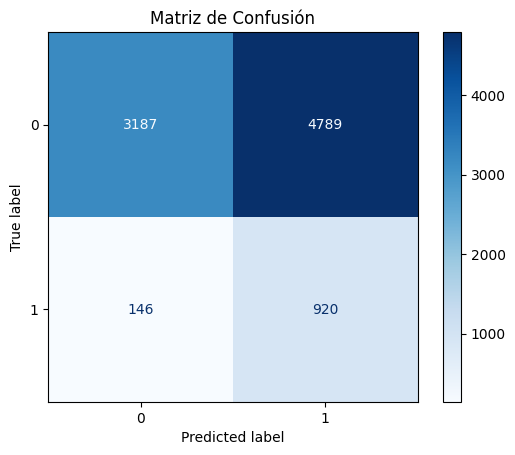

              precision    recall  f1-score   support

           0       0.96      0.40      0.56      7976
           1       0.16      0.86      0.27      1066

    accuracy                           0.45      9042
   macro avg       0.56      0.63      0.42      9042
weighted avg       0.86      0.45      0.53      9042

Verdaderos Negativos (TN): 3187
Falsos Positivos (FP): 4789
Falsos Negativos (FN): 146
Verdaderos Positivos (TP): 920
Ingresos esperados (I): 82360.64 euros


In [34]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan'], inplace=True)

# Convertir las categorías a valores numéricos
cat_int_feats = ['housing', 'contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo con los datos balanceados
# Cálculo de class_weight
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds, class_weight=class_weights)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')


model.save('modeloproy2_3.keras')

y
1    20525
0    14391
Name: count, dtype: int64
Epoch 1/50
1092/1092 [==============================] - 5s 3ms/step - loss: 0.7602 - accuracy: 0.6539 - val_loss: 1.5659 - val_accuracy: 0.3088
Epoch 2/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.5675 - accuracy: 0.6815 - val_loss: 1.5286 - val_accuracy: 0.2618
Epoch 3/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.5485 - accuracy: 0.6846 - val_loss: 1.5515 - val_accuracy: 0.3163
Epoch 4/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.5369 - accuracy: 0.6954 - val_loss: 1.3598 - val_accuracy: 0.3280
Epoch 5/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.5280 - accuracy: 0.6977 - val_loss: 1.2202 - val_accuracy: 0.4302
Epoch 6/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.5206 - accuracy: 0.7083 - val_loss: 1.2998 - val_accuracy: 0.3865
Epoch 7/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.5158 - a

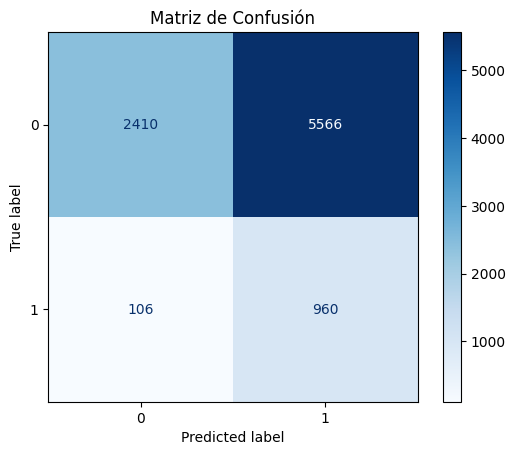

              precision    recall  f1-score   support

           0       0.96      0.30      0.46      7976
           1       0.15      0.90      0.25      1066

    accuracy                           0.37      9042
   macro avg       0.55      0.60      0.36      9042
weighted avg       0.86      0.37      0.44      9042

Verdaderos Negativos (TN): 2410
Falsos Positivos (FP): 5566
Falsos Negativos (FN): 106
Verdaderos Positivos (TP): 960
Ingresos esperados (I): 90708.23 euros


In [37]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo con los datos balanceados
# Cálculo de class_weight
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds, class_weight=class_weights)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy.keras')

y
1    20525
0    14391
Name: count, dtype: int64
Epoch 1/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.4975 - accuracy: 0.7608 - val_loss: 0.6086 - val_accuracy: 0.7014
Epoch 2/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4205 - accuracy: 0.8080 - val_loss: 0.5184 - val_accuracy: 0.7635
Epoch 3/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4095 - accuracy: 0.8156 - val_loss: 0.6054 - val_accuracy: 0.7127
Epoch 4/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3998 - accuracy: 0.8214 - val_loss: 0.5615 - val_accuracy: 0.7440
Epoch 5/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3934 - accuracy: 0.8267 - val_loss: 0.5808 - val_accuracy: 0.7390
Epoch 6/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3897 - accuracy: 0.8271 - val_loss: 0.5122 - val_accuracy: 0.7720
Epoch 7/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3867 - a

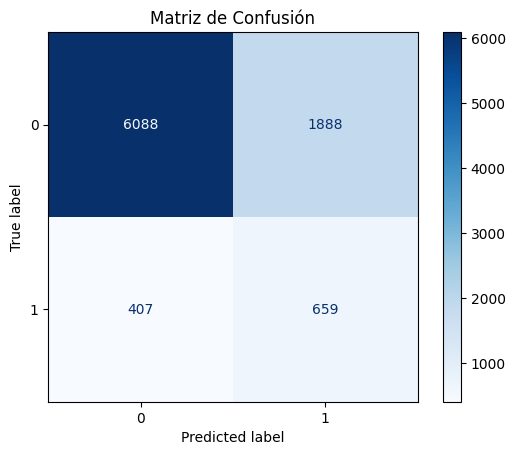

              precision    recall  f1-score   support

           0       0.94      0.76      0.84      7976
           1       0.26      0.62      0.36      1066

    accuracy                           0.75      9042
   macro avg       0.60      0.69      0.60      9042
weighted avg       0.86      0.75      0.79      9042

Verdaderos Negativos (TN): 6088
Falsos Positivos (FP): 1888
Falsos Negativos (FN): 407
Verdaderos Positivos (TP): 659
Ingresos esperados (I): 27355.35 euros


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.1).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_0.1.keras')

y
1    20525
0    14391
Name: count, dtype: int64
Epoch 1/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.4991 - accuracy: 0.7584 - val_loss: 0.5507 - val_accuracy: 0.7347
Epoch 2/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4231 - accuracy: 0.8077 - val_loss: 0.5192 - val_accuracy: 0.7690
Epoch 3/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.4067 - accuracy: 0.8150 - val_loss: 0.5271 - val_accuracy: 0.7624
Epoch 4/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3998 - accuracy: 0.8210 - val_loss: 0.5041 - val_accuracy: 0.7812
Epoch 5/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3946 - accuracy: 0.8241 - val_loss: 0.5648 - val_accuracy: 0.7415
Epoch 6/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3894 - accuracy: 0.8261 - val_loss: 0.5265 - val_accuracy: 0.7774
Epoch 7/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.3836 - a

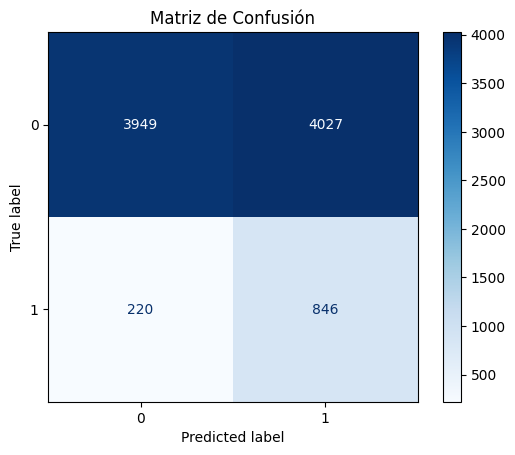

              precision    recall  f1-score   support

           0       0.95      0.50      0.65      7976
           1       0.17      0.79      0.28      1066

    accuracy                           0.53      9042
   macro avg       0.56      0.64      0.47      9042
weighted avg       0.86      0.53      0.61      9042

Verdaderos Negativos (TN): 3949
Falsos Positivos (FP): 4027
Falsos Negativos (FN): 220
Verdaderos Positivos (TP): 846
Ingresos esperados (I): 66750.29 euros


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.2).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_0.2.keras')

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.3).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_0.3.keras')

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.4).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_0.4.keras')